In [34]:
!pip install -q datasets scikit-learn pandas tqdm groq transformers accelerate
!pip install -q sentence-transformers

# Configuración

In [35]:
# ----------------- CONFIG -----------------
BACKEND = "groq"          # "groq"  o  "hf"

# Modelo segun backend:
#   groq -> "llama-3.1-8b-instant" (14.4k req/dia, el mas generoso),
#           "llama-3.3-70b-versatile", "gemma2-9b-it", "qwen-2.5-32b", "mixtral-8x7b-32768"
#   hf   -> "meta-llama/Llama-2-7b-chat-hf" (gated), "mistralai/Mistral-7B-Instruct-v0.3", etc.
MODEL = "llama-3.1-8b-instant"

LENGTH = "medium"         # "small" | "medium" | "large"  (medium ~128 tokens, como en el paper)

# Sub-muestreo para un primer run rapido. Subilos despues (None = todo).
N_BOOKS_PER_CLASS   = 10  # 10 members + 10 non-members
N_PASSAGES_PER_BOOK = 10  # el dataset trae ~30 por book
N_PERMUTATIONS      = 6   # 24 = todas (paper). 6 alcanza para un primer AUC

# Rate limiting (Groq free: ~30 req/min). Subi el sleep si te tira 429.
SLEEP_BETWEEN_CALLS = 2.1  # segundos. Para 'hf' poné 0.

SEED = 2319
# ------------------------------------------

# Claves (en Colab: icono de llave 🔑 a la izquierda -> "Secrets")
import os
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")  if BACKEND == "groq" else None
    HF_TOKEN     = userdata.get("HF_TOKEN")       if BACKEND == "hf"   else None
except Exception:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
    HF_TOKEN     = os.environ.get("HF_TOKEN")
print("Backend:", BACKEND, "| Modelo:", MODEL)

from groq import Groq

if BACKEND == "groq":
    assert GROQ_API_KEY is not None, "No se encontró GROQ_API_KEY en Colab Secrets"
    _client = Groq(api_key=GROQ_API_KEY)
    print("Cliente Groq creado correctamente")

Backend: groq | Modelo: llama-3.1-8b-instant
Cliente Groq creado correctamente


In [36]:
print("_client" in globals())

True


# 3. Cargar BookTection desde HuggingFace

In [37]:
import pandas as pd
from datasets import load_dataset

ds = load_dataset("avduarte333/BookTection", split="train")
df = ds.to_pandas()
df = df[df["Length"] == LENGTH].reset_index(drop=True)

# Limpiar filas rotas (#NAME? aparece en algunas celdas del CSV original)
opt_cols = ["Example_A", "Example_B", "Example_C", "Example_D"]
def ok(r): return all(isinstance(r[c], str) and r[c].strip() not in ("", "#NAME?") for c in opt_cols)
df = df[df.apply(ok, axis=1)].reset_index(drop=True)

print(f"{df['ID'].nunique()} books, {len(df)} pasajes (length={LENGTH})")
print("Members (1):", df[df.Label==1].ID.nunique(), "| Non-members (0):", df[df.Label==0].ID.nunique())
df.head(2)

165 books, 5494 pasajes (length=medium)
Members (1): 105 | Non-members (0): 60


,ID,Example_A,Example_B,Example_C,Example_D,Answer,Length,Label
0,1984_-_George_Orwell,"O'Brien had sat down beside the bed, so that h...",O'Brien positioned himself next to Winston's b...,O'Brien sat on the bed next to Winston so thei...,O'Brien took a seat on the bed next to Winston...,A,medium,1
1,1984_-_George_Orwell,The future belonged to the proles. And could h...,The future was owned by the proles. Winston wo...,The proles would inherit the future. Winston q...,The proles would come to rule the times ahead....,A,medium,1


# 4. Backend del modelo


In [38]:
def model_generate_fn(prefix):
    prompt = f"""
Complete the following text with ONLY the next word.

Text:
{prefix}

Next word:
"""
    r = _client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        max_tokens=5,
    )
    out = r.choices[0].message.content.strip()
    return out.split()[0] if out else ""

In [62]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import time

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def similarity(w1, w2):
    if not w1 or not w2:
        return 0.0
    e1 = embedder.encode([w1])
    e2 = embedder.encode([w2])
    cos = cosine_similarity(e1, e2)[0][0]
    return (cos + 1) / 2

def word_score(target_word, sampled_words):
    sampled_words = [w for w in sampled_words if w]
    if not sampled_words:
        return 0.0
    return np.mean([similarity(target_word, w) for w in sampled_words])

def simmia_score(text, model_generate_fn, non_member_prefix="", n_samples=3, max_words=20):
    words = text.split()[:max_words]
    ratios = []

    for i in range(1, len(words)):
        prefix = " ".join(words[:i])
        target_word = words[i]

        normal_samples = []
        perturbed_samples = []

        for _ in range(n_samples):
            normal_samples.append(model_generate_fn(prefix))
            time.sleep(SLEEP_BETWEEN_CALLS)

            perturbed_samples.append(model_generate_fn(non_member_prefix + " " + prefix))
            time.sleep(SLEEP_BETWEEN_CALLS)

        normal_score = word_score(target_word, normal_samples)
        perturbed_score = word_score(target_word, perturbed_samples)

        if normal_score > 1e-8:
            ratios.append(perturbed_score / normal_score)

    return -np.mean(ratios) if ratios else None

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [63]:
def get_correct_text(row):
    return row[f"Example_{row['Answer']}"]

texts_df = pd.DataFrame({
    "text": df.apply(get_correct_text, axis=1),
    "label": df["Label"]
})

texts_df = texts_df.sample(30, random_state=42).reset_index(drop=True)

print(texts_df["label"].value_counts())
texts_df.head()

label
1    19
0    11
Name: count, dtype: int64


,text,label
0,Baldini was beside himself. He wailed and lame...,1
1,--Miss Taylor married. It was Miss Taylor's lo...,1
2,"“He’s got a fine touch,” said Druot. “He’s got...",1
3,"“We’re eating out in the garden,” she said whe...",1
4,"This was madness, and shed probably be cut in ...",0


In [64]:
non_member_texts = texts_df[texts_df["label"] == 0]["text"].head(2).tolist()
non_member_prefix = " ".join(non_member_texts)[:500]

print(non_member_prefix[:300])

This was madness, and shed probably be cut in the first round. She sidled toward the door, wondering if she should make a break for it. Vanessa, meanwhile, had pushed herself to the front of the crowd of girls and stood with a hand on one hip, confident and strong. One by one, they were called over 


In [65]:
from tqdm import tqdm

results = []

for idx, row in tqdm(texts_df.iterrows(), total=len(texts_df)):
    score = simmia_score(
        text=row["text"],
        model_generate_fn=model_generate_fn,
        non_member_prefix=non_member_prefix,
        n_samples=1,
        max_words=12,
    )

    results.append({
        "idx": idx,
        "text": row["text"],
        "label": row["label"],
        "simmia_score": score
    })

    pd.DataFrame(results).to_csv("simmia_booktection_partial.csv", index=False)

results_df = pd.DataFrame(results)
results_df

100%|██████████| 30/30 [25:21<00:00, 50.71s/it]


,idx,text,label,simmia_score
0,0,Baldini was beside himself. He wailed and lame...,1,-0.937162
1,1,--Miss Taylor married. It was Miss Taylor's lo...,1,-0.960017
2,2,"“He’s got a fine touch,” said Druot. “He’s got...",1,-1.017918
3,3,"“We’re eating out in the garden,” she said whe...",1,-0.893157
4,4,"This was madness, and shed probably be cut in ...",0,-0.984114
5,5,"Stop it, Iris, Roman said, gathering them up a...",0,-1.005416
6,6,A double O number in our Service means you've ...,1,-0.984020
7,7,“I used to be ashamed. All the time. Because I...,0,-0.976324
8,8,Hunter is also a good driver in inclement weat...,0,-0.966244
9,9,"""Yes?"" said Harry eagerly. ""Now, don't ask me ...",1,-1.006946


In [66]:
results_df.sort_values("simmia_score")

,idx,text,label,simmia_score
10,10,“He did indeed. Black was tired of his double-...,1,-1.025396
13,13,"It was nearly midnight, and he was lying on hi...",1,-1.025338
26,26,But over in the neighboring town of Great Hang...,1,-1.020877
2,2,"“He’s got a fine touch,” said Druot. “He’s got...",1,-1.017918
9,9,"""Yes?"" said Harry eagerly. ""Now, don't ask me ...",1,-1.006946
5,5,"Stop it, Iris, Roman said, gathering them up a...",0,-1.005416
21,21,"You mean they like my parents, she said. They ...",0,-1.000624
14,14,"At some future day, it may be, I shall remembe...",1,-0.995584
4,4,"This was madness, and shed probably be cut in ...",0,-0.984114
17,17,But I pushed on. My best strategy was to divid...,0,-0.984071


In [67]:
results_df.groupby("label")["simmia_score"].mean()

,simmia_score
label,
0,-0.953619
1,-0.951938


In [68]:
results_df.groupby("label")["simmia_score"].agg(["mean","std"])

,mean,std
label,,
0,-0.953619,0.051219
1,-0.951938,0.061252


<Axes: >

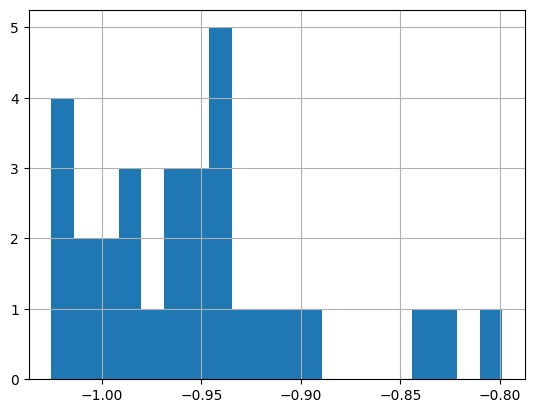

In [69]:
results_df["simmia_score"].hist(bins=20)

<Axes: title={'center': 'simmia_score'}, xlabel='label'>

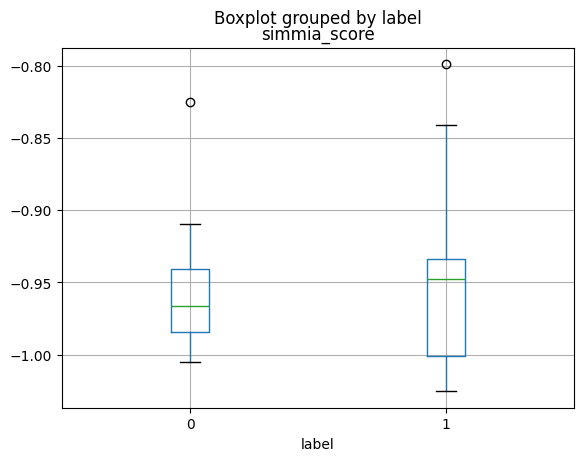

In [70]:
results_df.boxplot(column="simmia_score", by="label")

In [71]:
from sklearn.metrics import roc_auc_score

eval_df = results_df.dropna(subset=["simmia_score"])

auc = roc_auc_score(eval_df["label"], eval_df["simmia_score"])
auc_inv = roc_auc_score(eval_df["label"], -eval_df["simmia_score"])

print("AUC:", auc)
print("AUC invertido:", auc_inv)

AUC: 0.5119617224880382
AUC invertido: 0.48803827751196166


La implementación actual de SimMIA funciona técnicamente, pero no está mostrando una separación clara entre miembros y no miembros sobre BookTection. Los resultados obtenidos oscilan entre AUC≈0.5 y AUC≈0.6 al aumentar el tamaño de muestra, lo que sugiere que la señal capturada por esta adaptación black-box es débil.

Tomé SimMIA como una idea de comparar el comportamiento del modelo frente a un texto original y frente a una versión contextualizada/perturbada, pero lo llevé a un escenario black-box estricto, donde no tengo acceso a logits, probabilidades ni pérdidas token a token. En vez de medir likelihood o loss, hiciste que el modelo prediga la próxima palabra dado un prefijo del texto.